DME and matrix logarithm
==========================
Given enough copies of a mixed state $\rho$, density matrix exponentiation can be used to implement the operator $e^{-i\rho t}$ as a quantum circuit.

In this Notebook, we show how to transform this operator into a block encoding of $\rho$ itself.

Imports:

In [1]:
import scipy
import pennylane
import numpy as np
from numpy.polynomial import Polynomial, Chebyshev
from matplotlib import pyplot as plt
from QSP import compute_angles
from QSVT_circuit import construct_QSVT_circuit

Generate random mixed state $\rho$.

In [2]:
n_qubits = 3

def random_density_matrix(n_qubits):
    n = 2 ** n_qubits
    G = np.random.normal(0, 1, size=(n, n)) + 1j*np.random.normal(0, 1, size=(n, n))
    G /= np.sqrt(2)
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return rho

rho = random_density_matrix(n_qubits)


With access to $U = e^{-i\rho/2}$, a block encoding of $\sin(\rho/2)$ is obtained using a linear combination of unataries, since
$$\sin(\rho/2) = \frac{i}{2}(U - U^\dagger)$$

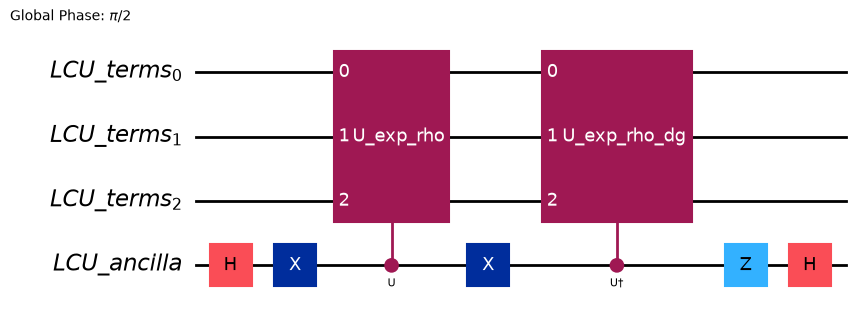

In [3]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import CXGate, RZGate, UnitaryGate


LCU_terms = QuantumRegister(n_qubits, "LCU_terms")
LCU_ancilla = QuantumRegister(1, "LCU_ancilla")
qc_sin = QuantumCircuit(LCU_terms, LCU_ancilla)

exp_rho = scipy.linalg.expm(-1j * rho/2)
U_exp_rho = UnitaryGate(exp_rho, label="U_exp_rho")
U_exp_rho_dg = U_exp_rho.adjoint()
U_exp_rho_dg.label = "U_exp_rho_dg"

qc_sin.h(LCU_ancilla)

# U controlled on ancilla = 0
qc_sin.x(LCU_ancilla)
qc_sin.append(U_exp_rho.control(label="U"), [LCU_ancilla[0], *LCU_terms])
qc_sin.x(LCU_ancilla)

# U† controlled on ancilla = 1
qc_sin.append(U_exp_rho_dg.control(label="U†"), [LCU_ancilla[0], *LCU_terms])

qc_sin.z(LCU_ancilla)
qc_sin.h(LCU_ancilla)

qc_sin.global_phase += np.pi / 2

qc_sin.draw('mpl')

We can extract $\rho$ from this by applying arcsin, an odd function. Approximate $P(x) \approx \frac{2}{\pi}\arcsin(x)$ by a truncated Maclaurin series (degree 5 in the compact example below), where the factor $\frac{2}{\pi}$ ensures that the polynomial satisfies the QSVT condition of being bounded by 1 on $[-1, 1]$.

In [4]:
def arcsin_maclaurin_coeffs(d):
    coeffs = np.zeros(d + 1)
    a = 1.0

    for k in range((d + 1) // 2):
        degree = 2 * k + 1
        if degree > d:
            break

        coeffs[degree] = a
        a *= (2 * k + 1)**2 / (2 * (k + 1) * (2 * k + 3))

    return coeffs

P = 2/np.pi * arcsin_maclaurin_coeffs(5)

Comparison with arcsin:

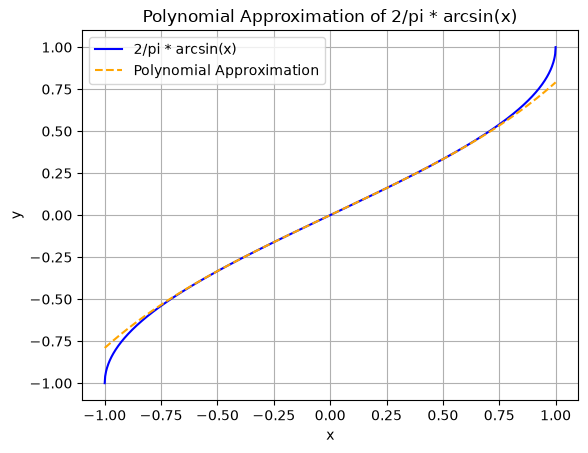

In [5]:
x = np.linspace(-1, 1, 1000)
y_arcsin = 2/np.pi * np.arcsin(x)
y_P = np.polyval(P[::-1], x)

plt.figure()
plt.plot(x, y_arcsin, label='2/pi * arcsin(x)', color='blue')
plt.plot(x, y_P, label='Polynomial Approximation', color='orange', linestyle='--')
plt.title('Polynomial Approximation of 2/pi * arcsin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

This is all we need to construct the QSVT circuit of a block encoding of $\rho$ via 
$$\frac{\rho}{\pi} = \frac{2}{\pi}\arcsin(\sin(\rho/2)) \approx P(\rho/2)$$

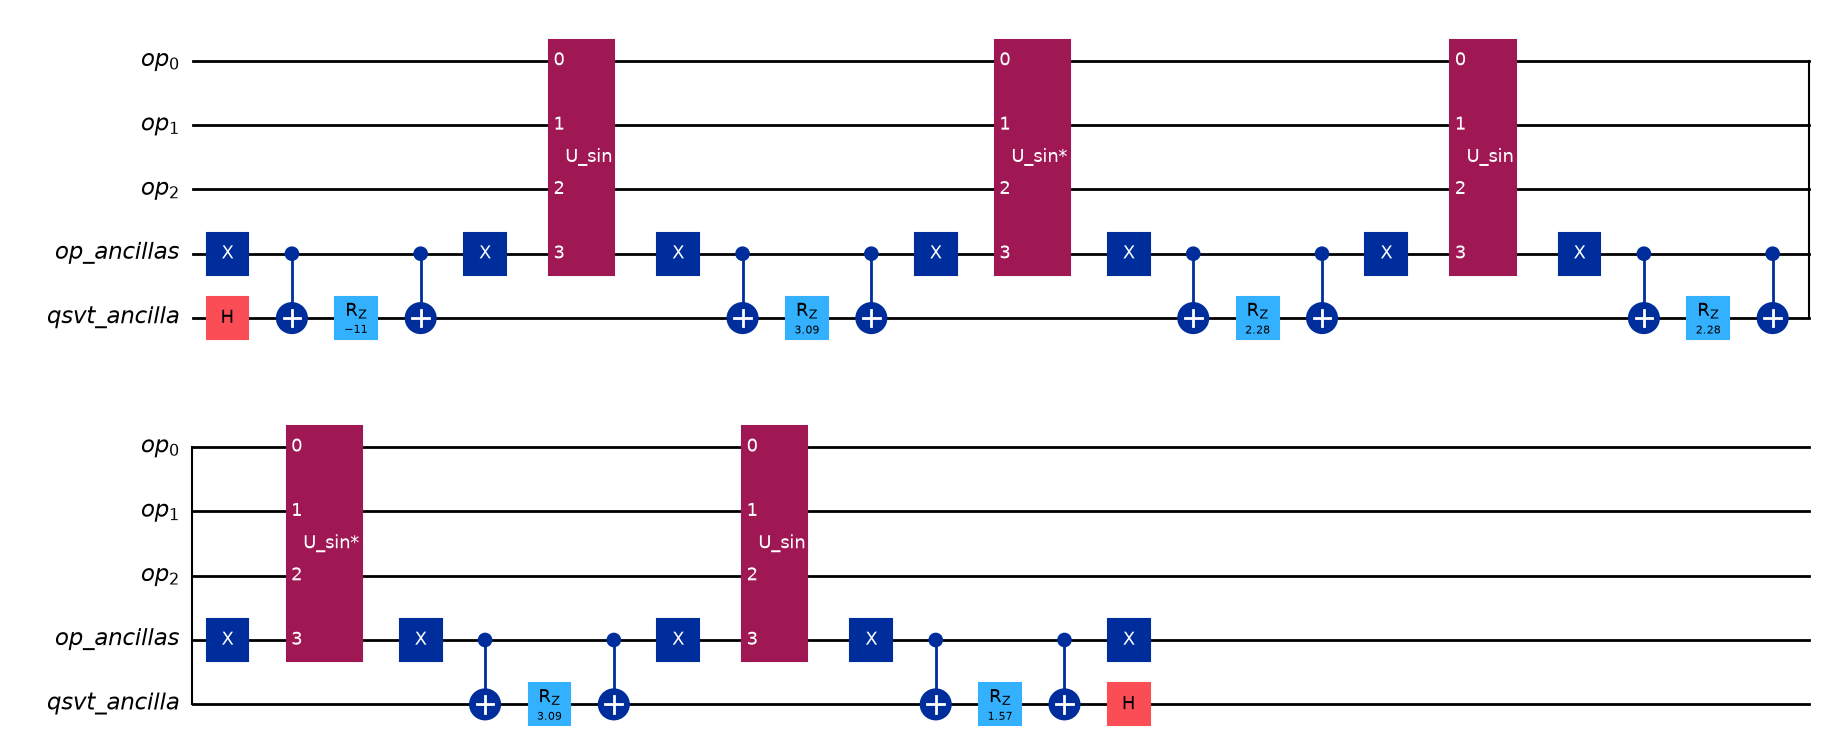

In [6]:
U_sin = qc_sin.to_gate(label="U_sin")
qc_arcsin = construct_QSVT_circuit(Polynomial(P).convert(kind=Chebyshev).coef, U_sin)
qc_arcsin.draw(output='mpl')

For a direct visual comparison with GQSP, construct the complete QSVT circuit again with every LCU operation written explicitly. In particular, the inverse LCU is inserted in reverse gate order with conjugated global phase; it is not obtained by asking Qiskit to decompose an inverse composite gate.

full-circuit difference: 4.321678179646351


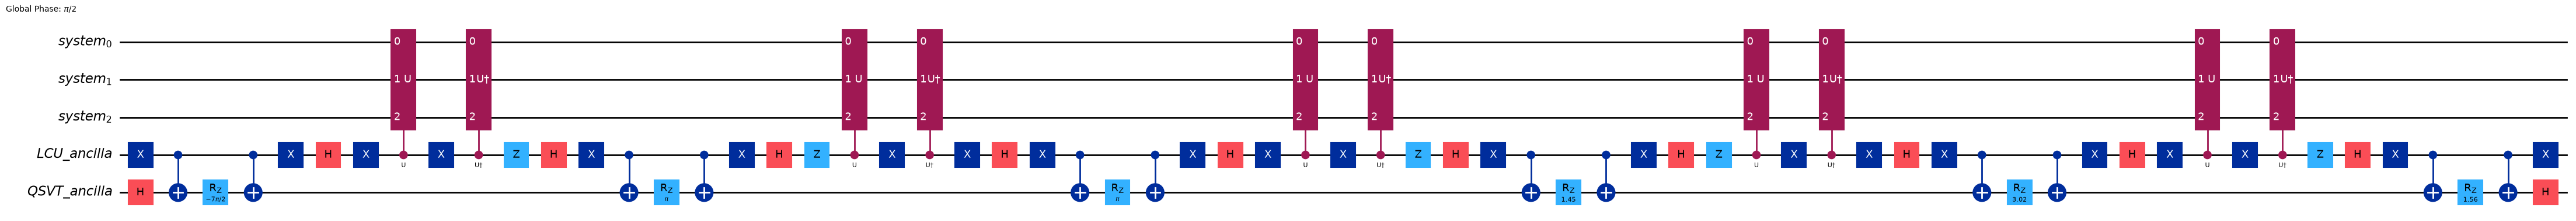

In [7]:
from qiskit.quantum_info import Operator

def construct_QSVT_with_explicit_LCU(P, unitary):
    phi = pennylane.poly_to_angles(P, "QSVT")

    system = QuantumRegister(n_qubits, "system")
    lcu_ancilla = QuantumRegister(1, "LCU_ancilla")
    qsvt_ancilla = QuantumRegister(1, "QSVT_ancilla")
    qc = QuantumCircuit(system, lcu_ancilla, qsvt_ancilla)

    U = UnitaryGate(unitary, label="U")
    U_dg = UnitaryGate(unitary.conj().T, label="U†")
    controlled_U = U.control(1, label="U")
    controlled_U_dg = U_dg.control(1, label="U†")

    def projector_rotation(angle):
        # Rotate the QSVT ancilla when the LCU block-encoding ancilla is |0>.
        qc.x(lcu_ancilla)
        qc.cx(lcu_ancilla, qsvt_ancilla)
        qc.rz(2 * angle, qsvt_ancilla)
        qc.cx(lcu_ancilla, qsvt_ancilla)
        qc.x(lcu_ancilla)

    def append_sine_LCU():
        # i/2 (U-U†), exactly as in qc_sin.
        qc.h(lcu_ancilla)
        qc.x(lcu_ancilla)
        qc.append(controlled_U, [lcu_ancilla[0], *system])
        qc.x(lcu_ancilla)
        qc.append(controlled_U_dg, [lcu_ancilla[0], *system])
        qc.z(lcu_ancilla)
        qc.h(lcu_ancilla)
        qc.global_phase += np.pi / 2

    def append_sine_LCU_dagger():
        # Exact adjoint: reverse the LCU gate order and conjugate its phase.
        qc.h(lcu_ancilla)
        qc.z(lcu_ancilla)
        qc.append(controlled_U, [lcu_ancilla[0], *system])
        qc.x(lcu_ancilla)
        qc.append(controlled_U_dg, [lcu_ancilla[0], *system])
        qc.x(lcu_ancilla)
        qc.h(lcu_ancilla)
        qc.global_phase -= np.pi / 2

    qc.h(qsvt_ancilla)
    for i in range(len(phi) // 2 - 1):
        projector_rotation(phi[2 * i])
        append_sine_LCU()
        projector_rotation(phi[2 * i + 1])
        append_sine_LCU_dagger()

    projector_rotation(phi[-2])
    append_sine_LCU()
    projector_rotation(phi[-1])
    qc.h(qsvt_ancilla)
    return qc

qc_qsvt_explicit_lcu = construct_QSVT_with_explicit_LCU(P, exp_rho)

# Confirm that the explicitly assembled circuit equals the compact construction.
explicit_difference = np.linalg.norm(
    Operator(qc_qsvt_explicit_lcu).data - Operator(qc_arcsin).data
)
print("full-circuit difference:", explicit_difference)

qc_qsvt_explicit_lcu.draw(output="mpl", fold=-1)

The top left block of this quantum circuit (represented as a matrix) is indeed close to a scaled version of $\rho$:

In [8]:
from qiskit.quantum_info import Operator

block = Operator(qc_arcsin).data[:2**n_qubits, :2**n_qubits]
target = rho / np.pi

print(np.linalg.norm(block - target)/np.linalg.norm(target))

2.9793749207131876e-06


The same transformation with GQSP
=================================

The LCU is not necessary if we compose the arcsin polynomial with the Laurent polynomial
$$
s(z)=\frac{i}{2}(z-z^{-1}).
$$
For an eigenvalue $z=e^{-i\lambda/2}$ of $U=e^{-i\rho/2}$, $s(z)=\sin(\lambda/2)$. Hence
$$
L(z)=P\!\left(\frac{i}{2}(z-z^{-1})\right)
$$
satisfies $L(U)=P(\sin(\rho/2))\approx\rho/\pi$. Moreover, $|L(z)|\leq 1$ on the unit circle because $s(e^{-i\theta})=\sin\theta\in[-1,1]$. Thus $L$ obeys the GQSP boundedness condition.

In [9]:
from math import comb

def compose_with_sine_laurent(P):
    """Coefficients of P(i/2 (z-z^-1)), returned as {exponent: coefficient}."""
    coefficients = {}

    for k, p_k in enumerate(P):
        # (z-z^-1)^k = sum_j binom(k,j) (-1)^j z^(k-2j)
        for j in range(k + 1):
            exponent = k - 2 * j
            term = p_k * (0.5j)**k * comb(k, j) * (-1)**j
            coefficients[exponent] = coefficients.get(exponent, 0.0j) + term

    return {k: v for k, v in coefficients.items() if not np.isclose(v, 0.0)}

L = compose_with_sine_laurent(P)
for exponent in sorted(L):
    print(f"z^{exponent:2d}: {L[exponent]: .10f}")

z^-5:  0.0000000000-0.0014920776j
z^-3:  0.0000000000+0.0207232999j
z^-1:  0.0000000000-0.3730193979j
z^ 1:  0.0000000000+0.3730193979j
z^ 3:  0.0000000000-0.0207232999j
z^ 5:  0.0000000000+0.0014920776j


PennyLane's GQSP phase solver accepts ordinary polynomials with non-negative exponents. Let $d=\deg(P)$ and shift the Laurent polynomial:
$$
Q(z)=z^dL(z).
$$
$Q$ has degree at most $2d$ and has the same magnitude as $L$ on the unit circle. We synthesize the ordinary GQSP phases for $Q$, but implement them using Theorem 6 of [Motlagh and Wiebe](https://arxiv.org/abs/2308.01501). Define the two signal operators
$$
A=|0\rangle\!\langle0|\otimes U+|1\rangle\!\langle1|\otimes I,
\qquad
A'=|0\rangle\!\langle0|\otimes I+|1\rangle\!\langle1|\otimes U^\dagger.
$$
Replacing $k$ instances of $A$ by $A'$ multiplies both encoded polynomials by $U^{-k}$ without adding queries. Here the ordinary polynomial $Q$ has degree $2d$ and we choose $k=d$, so the same phases directly encode
$$
U^{-d}Q(U)=L(U).
$$
Thus the shift is only an interface conversion for phase synthesis; it does not require a separate shift-correction circuit.

In [10]:
d = len(P) - 1
Q = np.zeros(2 * d + 1, dtype=complex)
for exponent, coefficient in L.items():
    Q[exponent + d] = coefficient

gqsp_angles = np.asarray(pennylane.poly_to_angles(Q, "GQSP"))
print("shifted GQSP polynomial coefficients:", Q)
print("angle array shape:", gqsp_angles.shape)

shifted GQSP polynomial coefficients: [0.-0.00149208j 0.+0.j         0.+0.0207233j  0.+0.j
 0.-0.3730194j  0.+0.j         0.+0.3730194j  0.+0.j
 0.-0.0207233j  0.+0.j         0.+0.00149208j]
angle array shape: (3, 11)


The following is the Qiskit version of PennyLane's GQSP decomposition with Theorem 6. The first $2d-k$ queries use $A$ (a 0-controlled $U$), and the last $k$ use $A'$ (a 1-controlled $U^\dagger$). Since $A'=(I\otimes U^\dagger)A$ and $I\otimes U^\dagger$ commutes with every signal and ancilla rotation, which $k$ instances are replaced is immaterial.

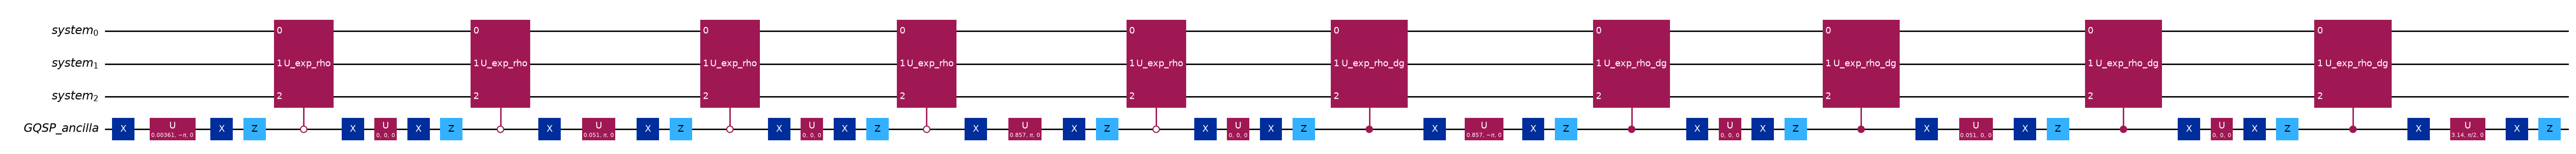

In [11]:
def construct_laurent_GQSP_circuit(unitary, angles, negative_powers=0):
    n_system = int(np.log2(unitary.shape[0]))
    system = QuantumRegister(n_system, "system")
    gqsp_ancilla = QuantumRegister(1, "GQSP_ancilla")
    qc = QuantumCircuit(system, gqsp_ancilla)

    theta, phi, lam = np.asarray(angles)

    def gqsp_rotation(k):
        # This matches PennyLane GQSP's U3 convention.
        qc.x(gqsp_ancilla)
        qc.u(2 * theta[k], phi[k], lam[k], gqsp_ancilla)
        qc.x(gqsp_ancilla)
        qc.z(gqsp_ancilla)

    signal = UnitaryGate(unitary, label="U_exp_rho")
    inverse_signal = UnitaryGate(unitary.conj().T, label="U_exp_rho_dg")
    degree = len(theta) - 1
    if not 0 <= negative_powers <= degree:
        raise ValueError("negative_powers must lie between 0 and the GQSP degree")

    gqsp_rotation(0)
    for k in range(1, degree + 1):
        if k <= degree - negative_powers:
            # A = diag(U, I)
            qc.append(signal.control(1, ctrl_state=0), [gqsp_ancilla[0], *system])
        else:
            # A' = diag(I, U†), as in Theorem 6
            qc.append(inverse_signal.control(1, ctrl_state=1), [gqsp_ancilla[0], *system])
        gqsp_rotation(k)

    return qc

qc_gqsp = construct_laurent_GQSP_circuit(exp_rho, gqsp_angles, negative_powers=d)
qc_gqsp.draw(output="mpl", fold=-1)

Verify both the polynomial identity and the encoded block. The first error below tests the synthesized GQSP circuit against $P(\sin(\rho/2))$; the second is the same truncation error relative to $\rho/\pi$ seen in the QSVT construction.

In [12]:
gqsp_block = Operator(qc_gqsp).data[:2**n_qubits, :2**n_qubits]

sin_rho = 0.5j * (exp_rho - exp_rho.conj().T)
polynomial_target = sum(
    p_k * np.linalg.matrix_power(sin_rho, k) for k, p_k in enumerate(P)
)

synthesis_error = np.linalg.norm(gqsp_block - polynomial_target) / np.linalg.norm(polynomial_target)
approximation_error = np.linalg.norm(gqsp_block - target) / np.linalg.norm(target)

print("GQSP synthesis error:       ", synthesis_error)
print("arcsin truncation error:   ", approximation_error)

GQSP synthesis error:        1.285034231306436e-13
arcsin truncation error:    2.979374915315218e-06


Ancilla count
-------------

* **QSVT route:** one LCU ancilla to block encode $\sin(\rho/2)$, plus one QSVT ancilla: **two ancillas**.
* **GQSP route:** one GQSP control qubit acting directly on $U=e^{-i\rho/2}$: **one ancilla**.

The GQSP construction therefore removes the LCU and saves one ancilla. For a degree-$d$ arcsin approximation, $Q$ has degree $2d$, so the Theorem 6 construction uses exactly $2d$ signal queries: $d$ controlled-$U$ queries and $d$ controlled-$U^\dagger$ queries. There is no separate $U^{-d}$ correction and no additional workspace.